MLP WIDE & DEEP - SOLO VARIABLES EPIDEMIOLÓGICAS
Objetivo: MAE train/test < 3, MAE picos < 3, R² > 0.9

Cargando train: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_red_neuronal_mlp_ancha_profunda\2_datos\1_raw\2_90_10\4_meteo_epi_2021-2026_1_rezagos_epi_train_90_10.xlsx
✅ Columnas epi presentes: 13
INGENIERÍA DE ATRIBUTOS EPIDEMIOLÓGICOS - WIDE & DEEP
Columnas epi originales: 13
Columnas tras ingeniería: 45

BÚSQUEDA DEL NÚMERO ÓPTIMO DE CARACTERÍSTICAS

Probando 5 características...
  MAE: 6.4992 | R²: 0.8022 | Peak MAE: 11.5538

Probando 8 características...
  MAE: 5.4777 | R²: 0.8443 | Peak MAE: 12.4544

Probando 11 características...
  MAE: 7.8727 | R²: 0.7389 | Peak MAE: 14.5817

Probando 14 características...
  MAE: 6.2568 | R²: 0.8204 | Peak MAE: 12.7200

Probando 17 características...
  MAE: 8.0519 | R²: 0.7016 | Peak MAE: 16.5941

Probando 20 características...
  MAE: 6.4391 | R²: 0.7733 | Peak MAE: 18.4548

Probando 23 características

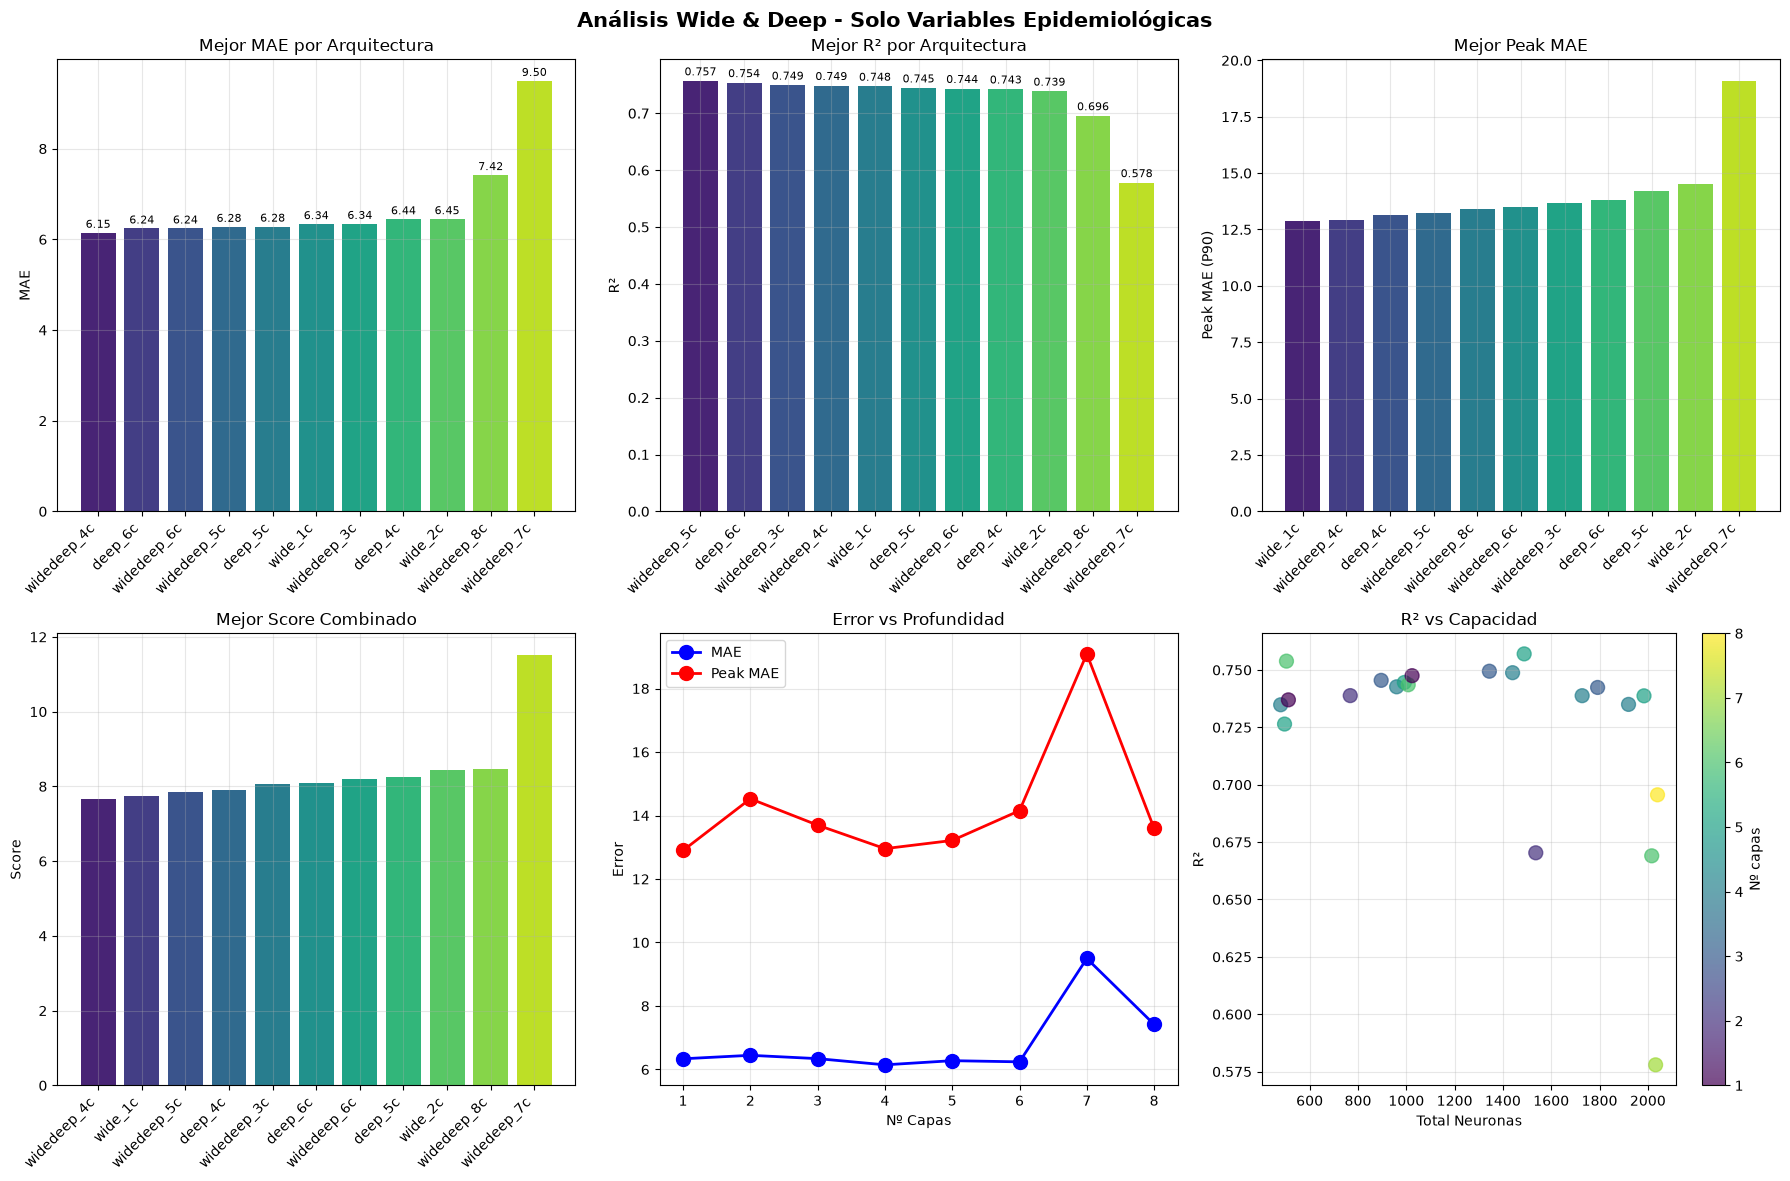

✅ Guardado: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_red_neuronal_mlp_ancha_profunda\2_datos\1_raw\2_90_10\3_resultados_epi_90_10\wide_deep_20260917_195743.png


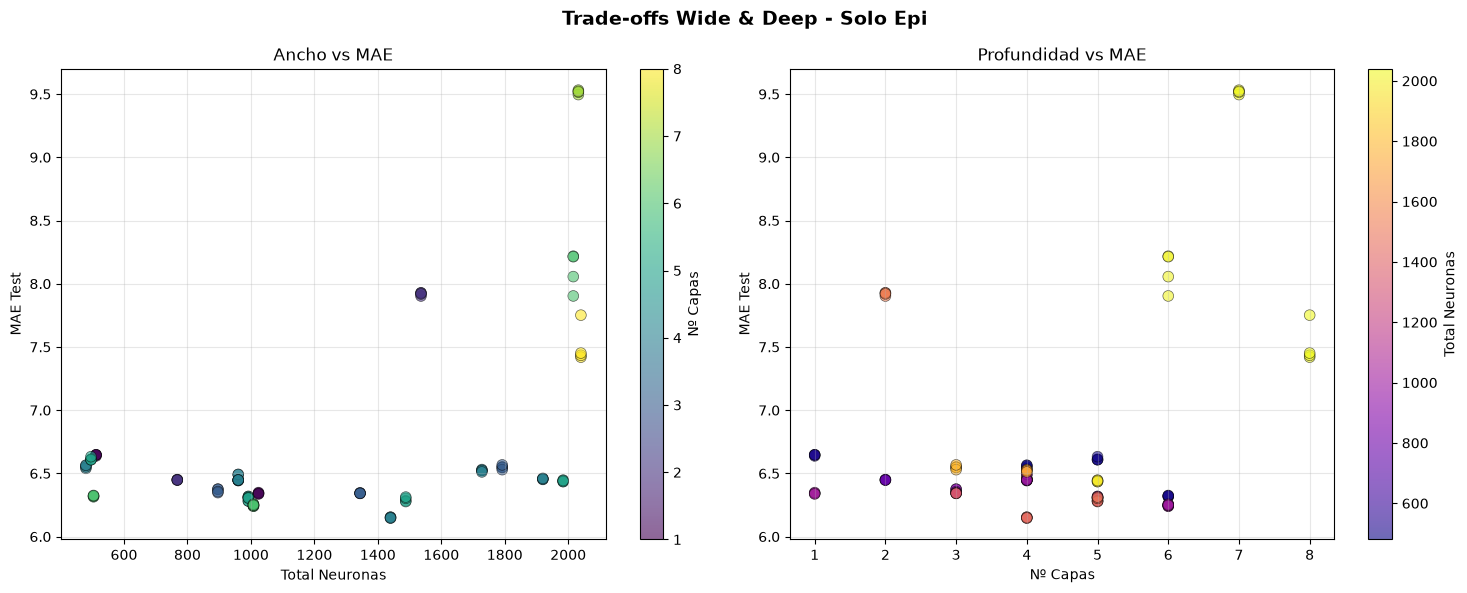

✅ Guardado: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_red_neuronal_mlp_ancha_profunda\2_datos\1_raw\2_90_10\3_resultados_epi_90_10\features_20260917_195743.png


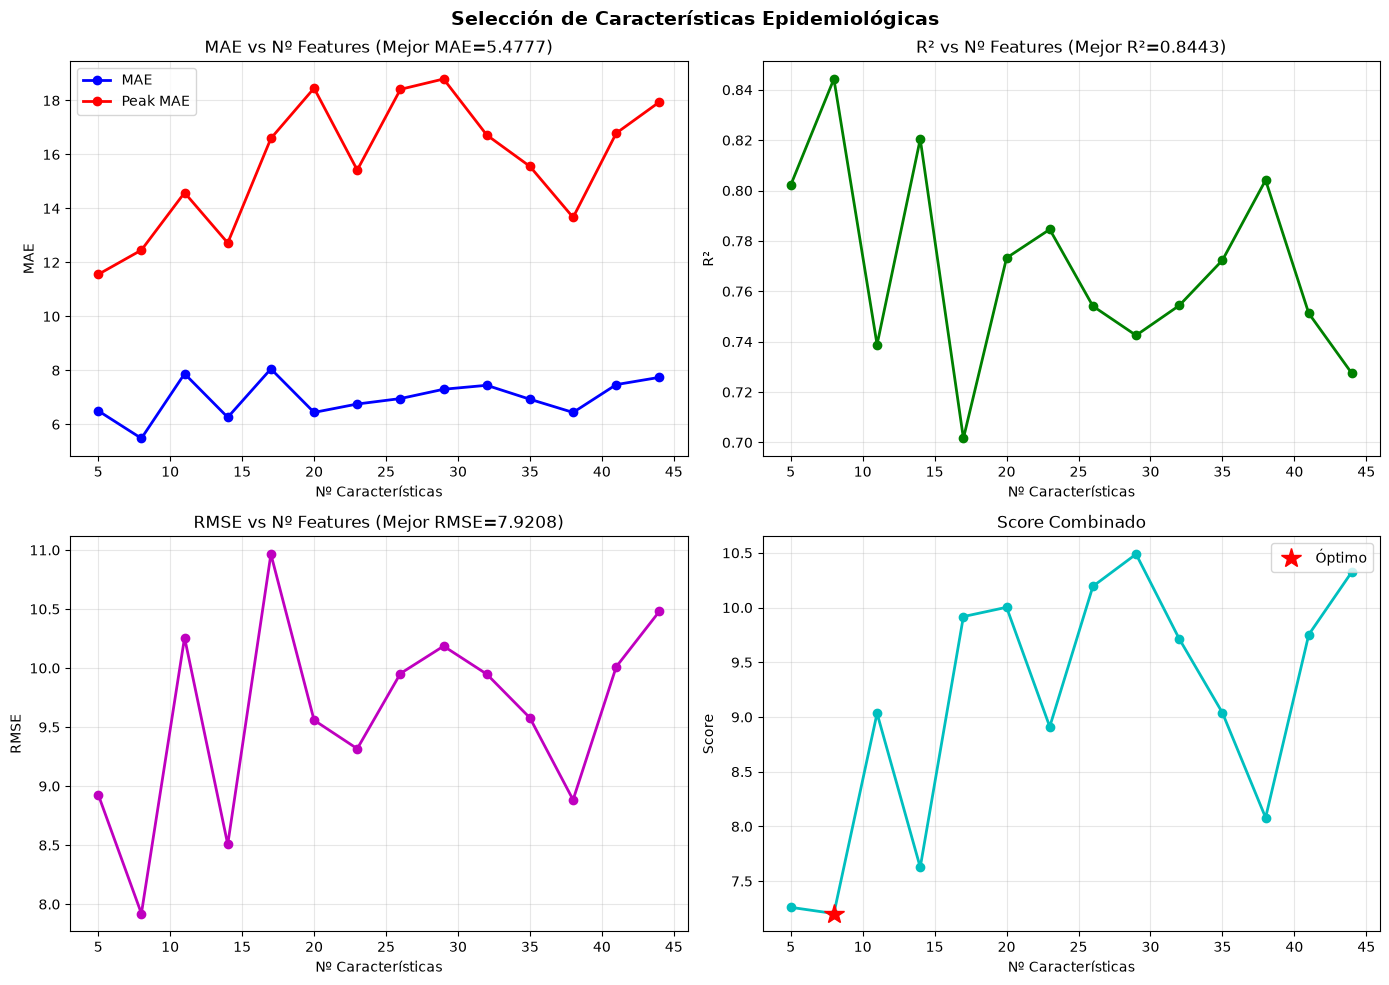

✅ Guardado: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_red_neuronal_mlp_ancha_profunda\2_datos\1_raw\2_90_10\3_resultados_epi_90_10\picos_20260917_195743.png


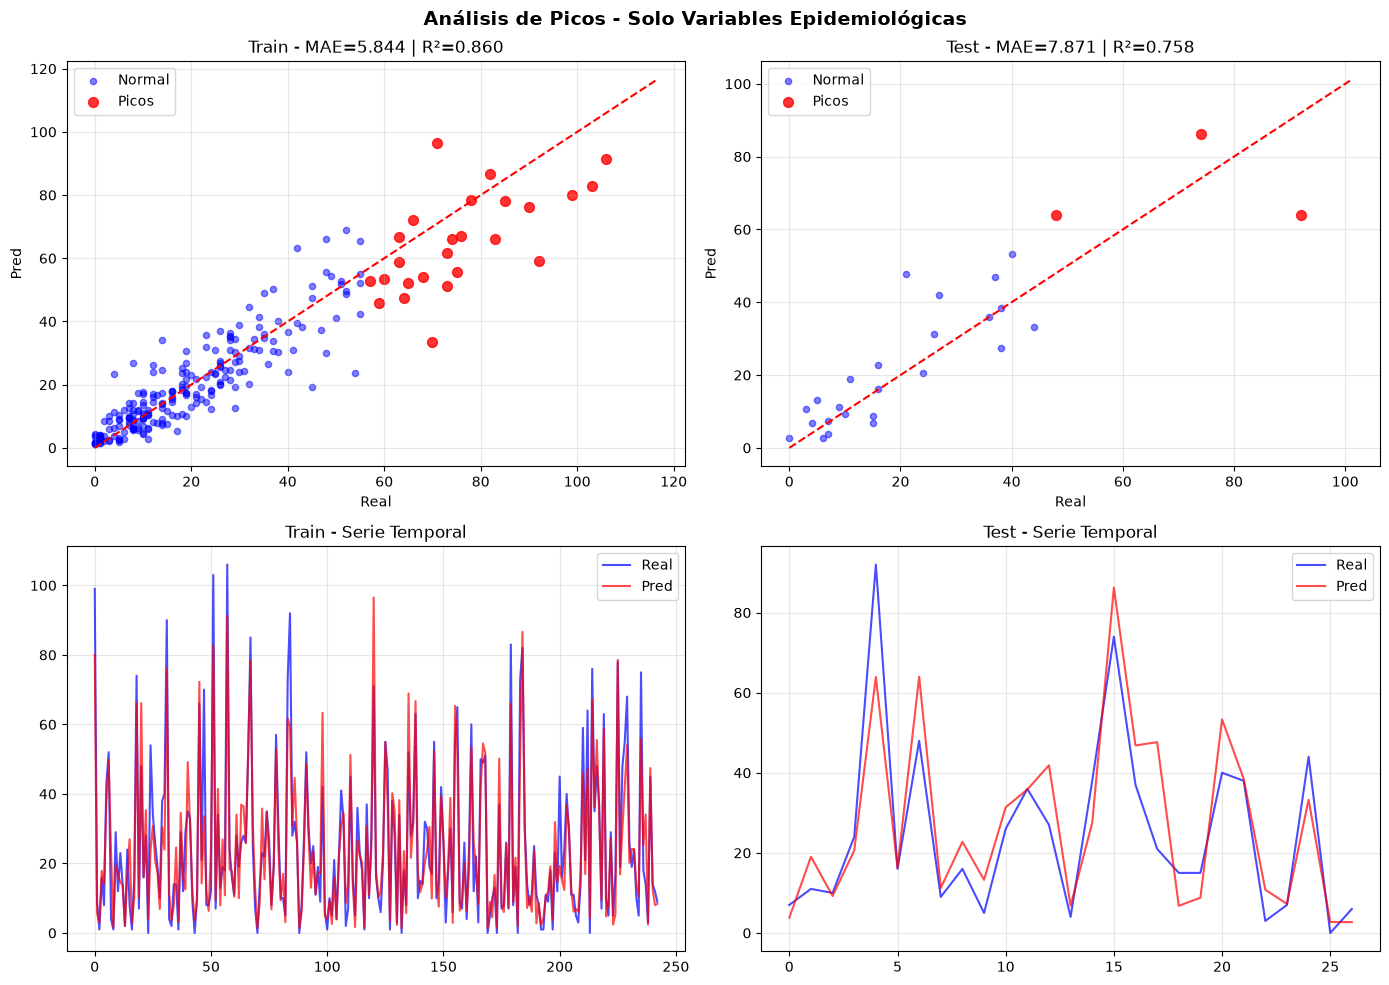

✅ Guardado: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_red_neuronal_mlp_ancha_profunda\2_datos\1_raw\2_90_10\3_resultados_epi_90_10\comparacion_20260917_195743.png


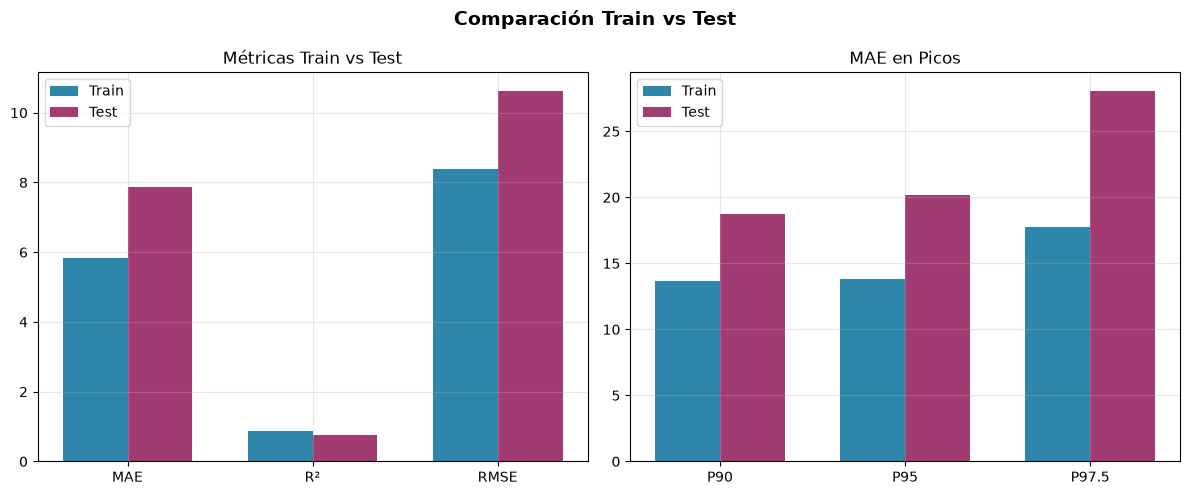


PROCESO COMPLETADO
Resultados: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_red_neuronal_mlp_ancha_profunda\2_datos\1_raw\2_90_10\3_resultados_epi_90_10\resultados_mlp_epi_20260917_195743.xlsx
Modelo: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_red_neuronal_mlp_ancha_profunda\2_datos\1_raw\2_90_10\3_resultados_epi_90_10\modelo_mlp_epi_guardado


In [1]:
"""
MLP Wide & Deep - SOLO VARIABLES EPIDEMIOLÓGICAS
Predictores: fecha, semana_epi, casos_dengue_lag_1 .. casos_dengue_lag_12
Objetivo: MAE train/test < 3 (promedio), MAE picos < 3, R² > 0.9
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
import warnings
import os
from datetime import datetime
import json
import pickle
import time

warnings.filterwarnings('ignore')


# ============================================================
# LISTA BLANCA DE VARIABLES EPIDEMIOLÓGICAS
# ============================================================
EPI_COLUMNS = [
    'semana_epi',
    *[f'casos_dengue_lag_{i}' for i in range(1, 13)],
]

# 'fecha' se usa solo para derivar features temporales (no como numérica cruda)
DATE_COL = 'fecha'
TARGET_COL = 'casos_dengue'


class DengueEpiFeatureEngineeringWideDeep:
    """
    Ingeniería de atributos + MLP Wide&Deep usando SOLO variables epidemiológicas.
    """

    def __init__(self, n_features_to_select=20):
        self.n_features_to_select = n_features_to_select
        self.scaler = StandardScaler()
        self.rfe = None
        self.selected_features = None
        self.feature_names = None
        self.mlp_model = None
        self.numeric_columns = None
        self.best_params = None
        self.peak_mae = None
        self.X_augmented_columns = None
        self.best_metrics = None
        self.cv_results = None
        self.train_val_metrics = None
        self.architecture_results = None
        self.best_architecture = None

    # ---------- UTILIDADES ----------
    def _filter_epi_columns(self, X):
        """Conserva únicamente columnas epidemiológicas presentes en X."""
        epi_present = [c for c in EPI_COLUMNS if c in X.columns]
        if not epi_present:
            raise ValueError("No se encontró ninguna columna epidemiológica en X.")
        return X[epi_present].copy()

    # ---------- INGENIERÍA DE ATRIBUTOS (SOLO EPI) ----------
    def create_interaction_features(self, X):
        """Interacciones entre rezagos de dengue (vecinos temporales)."""
        interaction_data = pd.DataFrame(index=X.index)
        pairs = [
            ('casos_dengue_lag_1', 'casos_dengue_lag_2', 'lag1_x_lag2'),
            ('casos_dengue_lag_1', 'casos_dengue_lag_4', 'lag1_x_lag4'),
            ('casos_dengue_lag_2', 'casos_dengue_lag_4', 'lag2_x_lag4'),
            ('casos_dengue_lag_4', 'casos_dengue_lag_8', 'lag4_x_lag8'),
            ('casos_dengue_lag_8', 'casos_dengue_lag_12', 'lag8_x_lag12'),
            ('casos_dengue_lag_1', 'casos_dengue_lag_12', 'lag1_x_lag12'),
        ]
        for c1, c2, name in pairs:
            if c1 in X.columns and c2 in X.columns:
                interaction_data[name] = X[c1] * X[c2]
        return interaction_data

    def create_polynomial_features(self, X):
        """Cuadrados de los rezagos más relevantes (capta no linealidad)."""
        important = ['casos_dengue_lag_1', 'casos_dengue_lag_2',
                     'casos_dengue_lag_4', 'casos_dengue_lag_8',
                     'casos_dengue_lag_12']
        poly = pd.DataFrame(index=X.index)
        for var in important:
            if var in X.columns:
                poly[f'{var}_squared'] = X[var] ** 2
        return poly

    def create_lag_aggregates(self, X):
        """Agregados estadísticos de los rezagos de dengue."""
        lag_aggs = pd.DataFrame(index=X.index)
        lag_cols = [c for c in X.columns if c.startswith('casos_dengue_lag_')]
        if len(lag_cols) >= 3:
            data = X[lag_cols]
            lag_aggs['dengue_lag_mean'] = data.mean(axis=1)
            lag_aggs['dengue_lag_std'] = data.std(axis=1)
            lag_aggs['dengue_lag_max'] = data.max(axis=1)
            lag_aggs['dengue_lag_min'] = data.min(axis=1)
            lag_aggs['dengue_lag_median'] = data.median(axis=1)
            lag_aggs['dengue_lag_sum'] = data.sum(axis=1)

            # Medias por bloques (corto, mediano, largo plazo)
            short = [c for c in lag_cols if any(f'lag_{i}' in c for i in (1, 2, 3, 4))]
            mid = [c for c in lag_cols if any(f'lag_{i}' in c for i in (5, 6, 7, 8))]
            long = [c for c in lag_cols if any(f'lag_{i}' in c for i in (9, 10, 11, 12))]
            if short:
                lag_aggs['dengue_lag_short_mean'] = X[short].mean(axis=1)
            if mid:
                lag_aggs['dengue_lag_mid_mean'] = X[mid].mean(axis=1)
            if long:
                lag_aggs['dengue_lag_long_mean'] = X[long].mean(axis=1)

            # Ratios de tendencia (corto vs largo)
            if short and long:
                lag_aggs['dengue_trend_short_long'] = (
                    X[short].mean(axis=1) / (X[long].mean(axis=1) + 1e-6))
        return lag_aggs

    def create_rolling_features(self, X):
        """Tendencias y diferencias entre rezagos (sin features estacionales).

        Nota: las features estacionales (week_sin/week_cos) se generan
        exclusivamente en create_date_features a partir de 'fecha' para
        evitar columnas duplicadas.
        """
        rolling = pd.DataFrame(index=X.index)

        # Tendencias entre rezagos
        if 'casos_dengue_lag_12' in X.columns:
            if 'casos_dengue_lag_8' in X.columns:
                rolling['dengue_trend_4w'] = (
                    X['casos_dengue_lag_12'] - X['casos_dengue_lag_8'])
            if 'casos_dengue_lag_4' in X.columns:
                rolling['dengue_trend_8w'] = (
                    X['casos_dengue_lag_12'] - X['casos_dengue_lag_4'])
        if 'casos_dengue_lag_2' in X.columns and 'casos_dengue_lag_1' in X.columns:
            rolling['dengue_diff_1_2'] = (
                X['casos_dengue_lag_1'] - X['casos_dengue_lag_2'])
        if 'casos_dengue_lag_4' in X.columns and 'casos_dengue_lag_2' in X.columns:
            rolling['dengue_diff_2_4'] = (
                X['casos_dengue_lag_2'] - X['casos_dengue_lag_4'])

        return rolling

    def create_date_features(self, X_full):
        """Extrae features temporales de 'fecha' (no se usa como numérica)."""
        date_feats = pd.DataFrame(index=X_full.index)
        if DATE_COL in X_full.columns:
            try:
                d = pd.to_datetime(X_full[DATE_COL], errors='coerce')
                date_feats['year'] = d.dt.year
                date_feats['month'] = d.dt.month
                date_feats['month_sin'] = np.sin(2 * np.pi * d.dt.month / 12)
                date_feats['month_cos'] = np.cos(2 * np.pi * d.dt.month / 12)
                date_feats['week_of_year'] = d.dt.isocalendar().week.astype(float)
                date_feats['week_sin'] = np.sin(2 * np.pi * date_feats['week_of_year'] / 52)
                date_feats['week_cos'] = np.cos(2 * np.pi * date_feats['week_of_year'] / 52)
                # Rellenar NaN de fechas inválidas
                date_feats = date_feats.fillna(0)
            except Exception:
                pass
        return date_feats

    def augment_features(self, X_full):
        """Aplica ingeniería SOLO sobre columnas epidemiológicas + fecha derivada."""
        X_epi = self._filter_epi_columns(X_full)
        features_list = [X_epi]

        inter = self.create_interaction_features(X_epi)
        if not inter.empty:
            features_list.append(inter)

        poly = self.create_polynomial_features(X_epi)
        if not poly.empty:
            features_list.append(poly)

        lags = self.create_lag_aggregates(X_epi)
        if not lags.empty:
            features_list.append(lags)

        rolling = self.create_rolling_features(X_epi)
        if not rolling.empty:
            features_list.append(rolling)

        date_f = self.create_date_features(X_full)
        if not date_f.empty:
            features_list.append(date_f)

        X_aug = pd.concat(features_list, axis=1)
        X_aug = X_aug.replace([np.inf, -np.inf], np.nan)
        X_aug = X_aug.fillna(X_aug.mean())
        X_aug = X_aug.fillna(0)
        return X_aug, X_epi

    # ---------- FIT / TRANSFORM ----------
    def fit_transform(self, X, y=None):
        print("=" * 60)
        print("INGENIERÍA DE ATRIBUTOS EPIDEMIOLÓGICOS - WIDE & DEEP")
        print("=" * 60)

        X_aug, X_epi = self.augment_features(X)
        self.numeric_columns = X_epi.columns.tolist()
        self.X_augmented_columns = X_aug.columns.tolist()
        self.feature_names = X_aug.columns.tolist()

        print(f"Columnas epi originales: {len(self.numeric_columns)}")
        print(f"Columnas tras ingeniería: {X_aug.shape[1]}")

        X_scaled = pd.DataFrame(
            self.scaler.fit_transform(X_aug),
            columns=X_aug.columns, index=X_aug.index)
        return X_scaled, X_aug

    def transform_features(self, X):
        X_aug, _ = self.augment_features(X)
        for col in self.X_augmented_columns:
            if col not in X_aug.columns:
                X_aug[col] = 0
        X_aug = X_aug[self.X_augmented_columns]
        X_scaled = pd.DataFrame(
            self.scaler.transform(X_aug),
            columns=X_aug.columns, index=X_aug.index)
        return X_scaled

    # ---------- SELECCIÓN DE FEATURES ----------
    def find_optimal_features(self, X_scaled, y, feature_range=None):
        if feature_range is None:
            feature_range = range(5, min(60, X_scaled.shape[1]), 3)

        print("\n" + "=" * 60)
        print("BÚSQUEDA DEL NÚMERO ÓPTIMO DE CARACTERÍSTICAS")
        print("=" * 60)

        results = []
        best_score = float('inf')
        best_n = None
        best_rfe = None
        best_selected = None
        best_metrics = None

        X_tr, X_val, y_tr, y_val = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42)

        for n in feature_range:
            if n > X_scaled.shape[1]:
                continue
            print(f"\nProbando {n} características...")
            rf = RandomForestRegressor(
                n_estimators=150, max_depth=10,
                min_samples_split=8, min_samples_leaf=4,
                random_state=42, n_jobs=-1)
            rfe = RFE(estimator=rf, n_features_to_select=n,
                      step=2, verbose=0)
            X_tr_sel = rfe.fit_transform(X_tr, y_tr)
            X_val_sel = rfe.transform(X_val)

            model = MLPRegressor(
                hidden_layer_sizes=(512, 256, 128),
                activation='relu', solver='adam',
                alpha=0.0005, learning_rate='adaptive',
                learning_rate_init=0.001, max_iter=800,
                random_state=42, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=25)
            model.fit(X_tr_sel, y_tr)
            y_pred = model.predict(X_val_sel)

            mae = mean_absolute_error(y_val, y_pred)
            r2 = r2_score(y_val, y_pred)
            rmse = np.sqrt(mean_squared_error(y_val, y_pred))

            thr = np.percentile(y_val, 90)
            mask = y_val > thr
            peak_mae = (mean_absolute_error(y_val[mask], y_pred[mask])
                        if mask.sum() > 0 else float('inf'))

            print(f"  MAE: {mae:.4f} | R²: {r2:.4f} | Peak MAE: {peak_mae:.4f}")

            results.append({
                'n_features': n, 'mae': mae, 'r2': r2,
                'rmse': rmse, 'peak_mae': peak_mae,
                'peak_threshold': thr, 'n_peaks': int(mask.sum())
            })

            score = (0.4 * mae + 0.4 * peak_mae + 0.2 * (1 - r2)
                     if peak_mae != float('inf') else mae)

            if score < best_score:
                best_score = score
                best_n = n
                best_rfe = rfe
                best_selected = X_scaled.columns[rfe.support_].tolist()
                best_metrics = {'mae': mae, 'r2': r2,
                                'rmse': rmse, 'peak_mae': peak_mae}

        print("\n" + "=" * 60)
        print(f"✅ ÓPTIMO: {best_n} características")
        print(f"   MAE={best_metrics['mae']:.4f} | R²={best_metrics['r2']:.4f} "
              f"| Peak MAE={best_metrics['peak_mae']:.4f}")
        print("=" * 60)

        self.selected_features = best_selected
        self.rfe = best_rfe
        self.best_metrics = best_metrics
        return best_n, results, best_metrics

    def transform_with_selected_features(self, X_scaled):
        return X_scaled[self.selected_features]

    # ---------- ARQUITECTURAS WIDE & DEEP ----------
    def _build_wide_deep_architectures(self):
        archs = {}

        archs['wide_1c'] = {
            'hidden_layer_sizes': [(512,), (1024,)],
            'desc': 'Wide - 1 capa ancha'}
        archs['wide_2c'] = {
            'hidden_layer_sizes': [(1024, 512), (512, 256)],
            'desc': 'Wide - 2 capas anchas'}

        archs['deep_4c'] = {
            'hidden_layer_sizes': [(256, 128, 64, 32), (512, 256, 128, 64)],
            'desc': 'Deep - 4 capas'}
        archs['deep_5c'] = {
            'hidden_layer_sizes': [(256, 128, 64, 32, 16),
                                   (512, 256, 128, 64, 32)],
            'desc': 'Deep - 5 capas'}
        archs['deep_6c'] = {
            'hidden_layer_sizes': [(512, 256, 128, 64, 32, 16),
                                   (256, 128, 64, 32, 16, 8)],
            'desc': 'Deep - 6 capas'}

        archs['widedeep_3c'] = {
            'hidden_layer_sizes': [(1024, 512, 256), (512, 256, 128),
                                   (768, 384, 192)],
            'desc': 'Wide&Deep - 3 capas'}
        archs['widedeep_4c'] = {
            'hidden_layer_sizes': [(1024, 512, 256, 128), (512, 256, 128, 64),
                                   (768, 384, 192, 96), (1024, 512, 128, 64)],
            'desc': 'Wide&Deep - 4 capas'}
        archs['widedeep_5c'] = {
            'hidden_layer_sizes': [(1024, 512, 256, 128, 64),
                                   (512, 256, 128, 64, 32),
                                   (768, 384, 192, 96, 48)],
            'desc': 'Wide&Deep - 5 capas'}
        archs['widedeep_6c'] = {
            'hidden_layer_sizes': [(1024, 512, 256, 128, 64, 32),
                                   (512, 256, 128, 64, 32, 16)],
            'desc': 'Wide&Deep - 6 capas'}
        archs['widedeep_7c'] = {
            'hidden_layer_sizes': [(1024, 512, 256, 128, 64, 32, 16)],
            'desc': 'Wide&Deep - 7 capas'}
        archs['widedeep_8c'] = {
            'hidden_layer_sizes': [(1024, 512, 256, 128, 64, 32, 16, 8)],
            'desc': 'Wide&Deep - 8 capas'}
        return archs

    def find_best_architecture(self, X_train, y_train, X_test, y_test):
        print("\n" + "=" * 60)
        print("BÚSQUEDA DE ARQUITECTURA WIDE & DEEP")
        print("=" * 60)

        architectures = self._build_wide_deep_architectures()
        alpha_values = [0.0001, 0.0005, 0.001, 0.005]

        results = []
        best_score = float('inf')
        best_config = None
        best_model = None
        best_metrics = None
        counter = 0

        for arch_name, arch_cfg in architectures.items():
            print(f"\n{arch_cfg['desc']} ({arch_name}):")
            for hidden in arch_cfg['hidden_layer_sizes']:
                for alpha in alpha_values:
                    counter += 1
                    print(f"  [{counter}] Capas={hidden}, α={alpha}",
                          end="", flush=True)
                    try:
                        t0 = time.time()
                        n_layers = len(hidden)
                        adaptive_alpha = alpha * (1 + 0.1 * n_layers)
                        model = MLPRegressor(
                            hidden_layer_sizes=hidden,
                            activation='relu', solver='adam',
                            alpha=adaptive_alpha,
                            learning_rate='adaptive',
                            learning_rate_init=0.001,
                            max_iter=1200, random_state=42,
                            early_stopping=True,
                            validation_fraction=0.15,
                            n_iter_no_change=30,
                            batch_size='auto')
                        model.fit(X_train, y_train)
                        t_train = time.time() - t0

                        y_pred_te = model.predict(X_test)
                        y_pred_tr = model.predict(X_train)

                        mae_te = mean_absolute_error(y_test, y_pred_te)
                        r2_te = r2_score(y_test, y_pred_te)
                        rmse_te = np.sqrt(mean_squared_error(y_test, y_pred_te))
                        mae_tr = mean_absolute_error(y_train, y_pred_tr)
                        r2_tr = r2_score(y_train, y_pred_tr)

                        thr = np.percentile(y_test, 90)
                        mask = y_test > thr
                        peak_mae = (mean_absolute_error(
                            y_test[mask], y_pred_te[mask])
                            if mask.sum() > 0 else float('inf'))

                        if peak_mae != float('inf'):
                            score = (0.4 * mae_te + 0.4 * peak_mae
                                     + 0.2 * (1 - r2_te))
                        else:
                            score = 0.6 * mae_te + 0.4 * (1 - r2_te)

                        gap = abs(mae_te - mae_tr)
                        if gap > 3.0:
                            score *= 1.15

                        print(f" | MAE={mae_te:.3f} | Peak={peak_mae:.3f} "
                              f"| R²={r2_te:.3f} | Score={score:.3f} "
                              f"| Gap={gap:.3f} | {t_train:.1f}s")

                        results.append({
                            'architecture': arch_name,
                            'desc': arch_cfg['desc'],
                            'layers': str(hidden),
                            'n_layers': n_layers,
                            'total_neurons': sum(hidden),
                            'alpha': adaptive_alpha,
                            'mae_train': mae_tr, 'r2_train': r2_tr,
                            'mae_test': mae_te, 'r2_test': r2_te,
                            'rmse_test': rmse_te,
                            'peak_mae_test': peak_mae,
                            'overfit_gap': gap,
                            'combined_score': score,
                            'train_time': t_train,
                            'model': model})

                        if score < best_score:
                            best_score = score
                            best_config = {
                                'architecture': arch_name,
                                'desc': arch_cfg['desc'],
                                'hidden_layers': hidden,
                                'n_layers': n_layers,
                                'neurons': hidden,
                                'total_neurons': sum(hidden),
                                'alpha': adaptive_alpha}
                            best_model = model
                            best_metrics = {
                                'mae_train': mae_tr, 'r2_train': r2_tr,
                                'mae_test': mae_te, 'r2_test': r2_te,
                                'rmse_test': rmse_te,
                                'peak_mae_test': peak_mae,
                                'overfit_gap': gap,
                                'combined_score': score,
                                'train_time': t_train}
                    except Exception as e:
                        print(f" | Error: {str(e)[:60]}")
                        continue

        df_res = pd.DataFrame([
            {k: v for k, v in r.items() if k != 'model'}
            for r in results])

        print("\n" + "=" * 60)
        print("✅ MEJOR ARQUITECTURA")
        print("=" * 60)
        print(f"Tipo: {best_config['desc']}")
        print(f"Capas: {best_config['hidden_layers']}")
        print(f"Alpha: {best_config['alpha']:.5f}")
        print(f"MAE Test: {best_metrics['mae_test']:.4f}")
        print(f"R² Test: {best_metrics['r2_test']:.4f}")
        print(f"Peak MAE: {best_metrics['peak_mae_test']:.4f}")
        print(f"Gap: {best_metrics['overfit_gap']:.4f}")

        self.architecture_results = df_res
        self.best_architecture = best_config
        self.mlp_model = best_model
        self.best_metrics = {
            'mae': best_metrics['mae_test'],
            'r2': best_metrics['r2_test'],
            'rmse': best_metrics['rmse_test'],
            'peak_mae': best_metrics['peak_mae_test']}
        self.train_val_metrics = {
            'mae_train': best_metrics['mae_train'],
            'r2_train': best_metrics['r2_train'],
            'mae_test': best_metrics['mae_test'],
            'r2_test': best_metrics['r2_test'],
            'peak_mae_test': best_metrics['peak_mae_test'],
            'overfit_gap': best_metrics['overfit_gap'],
            'best_params': {
                'hidden_layer_sizes': best_config['hidden_layers'],
                'activation': 'relu', 'solver': 'adam',
                'alpha': best_config['alpha'],
                'learning_rate': 'adaptive',
                'learning_rate_init': 0.001,
                'max_iter': 1200, 'early_stopping': True,
                'validation_fraction': 0.15, 'n_iter_no_change': 30}}
        return best_config, best_model, best_metrics

    # ---------- EVALUACIÓN ----------
    def evaluate_model_detailed(self, X_test, y_test, dataset_name="Test"):
        y_pred = self.mlp_model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        peak_metrics = {}
        for p in [90, 95, 97.5]:
            thr = np.percentile(y_test, p)
            mask = y_test > thr
            if mask.sum() > 0:
                peak_metrics[f'P{p}_MAE'] = mean_absolute_error(
                    y_test[mask], y_pred[mask])
                peak_metrics[f'P{p}_R2'] = (
                    r2_score(y_test[mask], y_pred[mask])
                    if len(y_test[mask]) > 1 else np.nan)
                peak_metrics[f'P{p}_Threshold'] = thr
                peak_metrics[f'P{p}_Count'] = int(mask.sum())

        print(f"\n{'='*60}\nMÉTRICAS - {dataset_name}\n{'='*60}")
        print(f"MAE: {mae:.4f} | R²: {r2:.4f} | RMSE: {rmse:.4f}")
        for k, v in peak_metrics.items():
            if isinstance(v, float):
                print(f"  {k}: {v:.4f}")
            else:
                print(f"  {k}: {v}")

        return {'MAE': mae, 'R2': r2, 'RMSE': rmse,
                'peak_metrics': peak_metrics,
                'predictions': y_pred,
                'actual': y_test.values if hasattr(y_test, 'values') else y_test}


# ============================================================
# GRÁFICOS
# ============================================================
def plot_architecture_results(df, save_path=None):
    if df is None or len(df) == 0:
        return None
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    ax1 = axes[0, 0]
    arch = df.groupby('architecture')['mae_test'].min().sort_values()
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(arch)))
    bars = ax1.bar(range(len(arch)), arch.values, color=colors)
    ax1.set_xticks(range(len(arch)))
    ax1.set_xticklabels(arch.index, rotation=45, ha='right')
    ax1.set_ylabel('MAE'); ax1.set_title('Mejor MAE por Arquitectura')
    ax1.grid(True, alpha=0.3)
    for b, v in zip(bars, arch.values):
        ax1.text(b.get_x() + b.get_width()/2, v + 0.05, f'{v:.2f}',
                 ha='center', va='bottom', fontsize=8)

    ax2 = axes[0, 1]
    r2 = df.groupby('architecture')['r2_test'].max().sort_values(ascending=False)
    bars = ax2.bar(range(len(r2)), r2.values, color=colors)
    ax2.set_xticks(range(len(r2)))
    ax2.set_xticklabels(r2.index, rotation=45, ha='right')
    ax2.set_ylabel('R²'); ax2.set_title('Mejor R² por Arquitectura')
    ax2.grid(True, alpha=0.3)
    for b, v in zip(bars, r2.values):
        ax2.text(b.get_x() + b.get_width()/2, v + 0.005, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=8)

    ax3 = axes[0, 2]
    pk = df.groupby('architecture')['peak_mae_test'].min().sort_values()
    bars = ax3.bar(range(len(pk)), pk.values, color=colors)
    ax3.set_xticks(range(len(pk)))
    ax3.set_xticklabels(pk.index, rotation=45, ha='right')
    ax3.set_ylabel('Peak MAE (P90)'); ax3.set_title('Mejor Peak MAE')
    ax3.grid(True, alpha=0.3)

    ax4 = axes[1, 0]
    sc = df.groupby('architecture')['combined_score'].min().sort_values()
    bars = ax4.bar(range(len(sc)), sc.values, color=colors)
    ax4.set_xticks(range(len(sc)))
    ax4.set_xticklabels(sc.index, rotation=45, ha='right')
    ax4.set_ylabel('Score'); ax4.set_title('Mejor Score Combinado')
    ax4.grid(True, alpha=0.3)

    ax5 = axes[1, 1]
    best_l = df.loc[df.groupby('n_layers')['mae_test'].idxmin()].sort_values('n_layers')
    ax5.plot(best_l['n_layers'], best_l['mae_test'], 'bo-',
             linewidth=2, markersize=10, label='MAE')
    ax5.plot(best_l['n_layers'], best_l['peak_mae_test'], 'ro-',
             linewidth=2, markersize=10, label='Peak MAE')
    ax5.set_xlabel('Nº Capas'); ax5.set_ylabel('Error')
    ax5.set_title('Error vs Profundidad'); ax5.legend(); ax5.grid(True, alpha=0.3)

    ax6 = axes[1, 2]
    best_n = df.loc[df.groupby('total_neurons')['r2_test'].idxmax()].sort_values('total_neurons')
    ax6.scatter(best_n['total_neurons'], best_n['r2_test'],
                c=best_n['n_layers'], cmap='viridis', s=100, alpha=0.7)
    ax6.set_xlabel('Total Neuronas'); ax6.set_ylabel('R²')
    ax6.set_title('R² vs Capacidad'); ax6.grid(True, alpha=0.3)
    plt.colorbar(ax6.collections[0], ax=ax6, label='Nº capas')

    plt.suptitle('Análisis Wide & Deep - Solo Variables Epidemiológicas',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Guardado: {save_path}")
    plt.show()
    return fig


def plot_feature_selection_results(results, best_metrics, save_path=None):
    df = pd.DataFrame(results)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax1 = axes[0, 0]
    ax1.plot(df['n_features'], df['mae'], 'bo-', label='MAE', linewidth=2)
    ax1.plot(df['n_features'], df['peak_mae'], 'ro-', label='Peak MAE', linewidth=2)
    ax1.set_xlabel('Nº Características'); ax1.set_ylabel('MAE')
    ax1.set_title(f'MAE vs Nº Features (Mejor MAE={best_metrics["mae"]:.4f})')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2 = axes[0, 1]
    ax2.plot(df['n_features'], df['r2'], 'go-', linewidth=2)
    ax2.set_xlabel('Nº Características'); ax2.set_ylabel('R²')
    ax2.set_title(f'R² vs Nº Features (Mejor R²={best_metrics["r2"]:.4f})')
    ax2.grid(True, alpha=0.3)

    ax3 = axes[1, 0]
    ax3.plot(df['n_features'], df['rmse'], 'mo-', linewidth=2)
    ax3.set_xlabel('Nº Características'); ax3.set_ylabel('RMSE')
    ax3.set_title(f'RMSE vs Nº Features (Mejor RMSE={best_metrics["rmse"]:.4f})')
    ax3.grid(True, alpha=0.3)

    ax4 = axes[1, 1]
    score = 0.4 * df['mae'] + 0.4 * df['peak_mae'] + 0.2 * (1 - df['r2'])
    ax4.plot(df['n_features'], score, 'co-', linewidth=2)
    ax4.plot(df['n_features'][score.idxmin()], score.min(),
             'r*', markersize=15, label='Óptimo')
    ax4.set_xlabel('Nº Características'); ax4.set_ylabel('Score')
    ax4.set_title('Score Combinado'); ax4.legend(); ax4.grid(True, alpha=0.3)

    plt.suptitle('Selección de Características Epidemiológicas',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Guardado: {save_path}")
    plt.show()
    return fig


def plot_peak_analysis(y_train, y_test, train_m, test_m, save_path=None):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax1 = axes[0, 0]
    a, p = train_m['actual'], train_m['predictions']
    thr = np.percentile(a, 90); m = a > thr
    ax1.scatter(a[~m], p[~m], alpha=0.5, color='blue', label='Normal', s=20)
    ax1.scatter(a[m], p[m], alpha=0.8, color='red', label='Picos', s=50)
    mn, mx = min(a.min(), p.min())*0.9, max(a.max(), p.max())*1.1
    ax1.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
    ax1.set_xlabel('Real'); ax1.set_ylabel('Pred')
    ax1.set_title(f'Train - MAE={train_m["MAE"]:.3f} | R²={train_m["R2"]:.3f}')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2 = axes[0, 1]
    a, p = test_m['actual'], test_m['predictions']
    thr = np.percentile(a, 90); m = a > thr
    ax2.scatter(a[~m], p[~m], alpha=0.5, color='blue', label='Normal', s=20)
    ax2.scatter(a[m], p[m], alpha=0.8, color='red', label='Picos', s=50)
    mn, mx = min(a.min(), p.min())*0.9, max(a.max(), p.max())*1.1
    ax2.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
    ax2.set_xlabel('Real'); ax2.set_ylabel('Pred')
    ax2.set_title(f'Test - MAE={test_m["MAE"]:.3f} | R²={test_m["R2"]:.3f}')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    ax3 = axes[1, 0]
    ax3.plot(train_m['actual'], 'b-', label='Real', alpha=0.7)
    ax3.plot(train_m['predictions'], 'r-', label='Pred', alpha=0.7)
    ax3.set_title('Train - Serie Temporal'); ax3.legend(); ax3.grid(True, alpha=0.3)

    ax4 = axes[1, 1]
    ax4.plot(test_m['actual'], 'b-', label='Real', alpha=0.7)
    ax4.plot(test_m['predictions'], 'r-', label='Pred', alpha=0.7)
    ax4.set_title('Test - Serie Temporal'); ax4.legend(); ax4.grid(True, alpha=0.3)

    plt.suptitle('Análisis de Picos - Solo Variables Epidemiológicas',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Guardado: {save_path}")
    plt.show()
    return fig


def plot_wide_deep_analysis(df, save_path=None):
    if df is None or len(df) == 0:
        return None
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    ax1 = axes[0]
    sc = ax1.scatter(df['total_neurons'], df['mae_test'],
                     c=df['n_layers'], cmap='viridis', s=60,
                     alpha=0.6, edgecolors='black', linewidth=0.5)
    ax1.set_xlabel('Total Neuronas'); ax1.set_ylabel('MAE Test')
    ax1.set_title('Ancho vs MAE'); ax1.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax1, label='Nº Capas')

    ax2 = axes[1]
    sc = ax2.scatter(df['n_layers'], df['mae_test'],
                     c=df['total_neurons'], cmap='plasma', s=60,
                     alpha=0.6, edgecolors='black', linewidth=0.5)
    ax2.set_xlabel('Nº Capas'); ax2.set_ylabel('MAE Test')
    ax2.set_title('Profundidad vs MAE'); ax2.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax2, label='Total Neuronas')

    plt.suptitle('Trade-offs Wide & Deep - Solo Epi',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Guardado: {save_path}")
    plt.show()
    return fig


def plot_performance_comparison(train_m, test_m, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax1 = axes[0]
    metrics = ['MAE', 'R²', 'RMSE']
    tv = [train_m['MAE'], train_m['R2'], train_m['RMSE']]
    te = [test_m['MAE'], test_m['R2'], test_m['RMSE']]
    x = np.arange(len(metrics)); w = 0.35
    ax1.bar(x - w/2, tv, w, label='Train', color='#2E86AB')
    ax1.bar(x + w/2, te, w, label='Test', color='#A23B72')
    ax1.set_xticks(x); ax1.set_xticklabels(metrics)
    ax1.set_title('Métricas Train vs Test'); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2 = axes[1]
    ps = [90, 95, 97.5]
    tv = [train_m['peak_metrics'].get(f'P{p}_MAE', 0) for p in ps]
    te = [test_m['peak_metrics'].get(f'P{p}_MAE', 0) for p in ps]
    x = np.arange(len(ps))
    ax2.bar(x - w/2, tv, w, label='Train', color='#2E86AB')
    ax2.bar(x + w/2, te, w, label='Test', color='#A23B72')
    ax2.set_xticks(x); ax2.set_xticklabels([f'P{p}' for p in ps])
    ax2.set_title('MAE en Picos'); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.suptitle('Comparación Train vs Test', fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Guardado: {save_path}")
    plt.show()
    return fig


def save_detailed_results(results, feature_results, arch_results,
                          best_metrics, selected_features, best_params,
                          train_val_metrics, filepath):
    try:
        with pd.ExcelWriter(filepath, engine='openpyxl') as w:
            pd.DataFrame({
                'Dataset': ['Train', 'Test'],
                'MAE': [results['train']['MAE'], results['test']['MAE']],
                'R2': [results['train']['R2'], results['test']['R2']],
                'RMSE': [results['train']['RMSE'], results['test']['RMSE']]
            }).to_excel(w, sheet_name='Métricas', index=False)

            peak = []
            for ds in ['train', 'test']:
                for p in [90, 95, 97.5]:
                    k = f'P{p}_MAE'
                    if k in results[ds]['peak_metrics']:
                        peak.append({
                            'Dataset': ds.capitalize(), 'Percentil': p,
                            'MAE_Pico': results[ds]['peak_metrics'][f'P{p}_MAE'],
                            'R2_Pico': results[ds]['peak_metrics'][f'P{p}_R2'],
                            'Threshold': results[ds]['peak_metrics'][f'P{p}_Threshold'],
                            'N_Picos': results[ds]['peak_metrics'][f'P{p}_Count']})
            if peak:
                pd.DataFrame(peak).to_excel(w, sheet_name='Métricas_Picos', index=False)

            pd.DataFrame({'Feature': selected_features}).to_excel(
                w, sheet_name='Características_Seleccionadas', index=False)

            pd.DataFrame({
                'Métrica': ['MAE', 'R²', 'RMSE', 'MAE_Picos(P90)'],
                'Valor': [best_metrics['mae'], best_metrics['r2'],
                          best_metrics['rmse'], best_metrics['peak_mae']]
            }).to_excel(w, sheet_name='Mejor_Modelo', index=False)

            if best_params:
                pd.DataFrame({
                    'Parámetro': list(best_params.keys()),
                    'Valor': [str(v) if isinstance(v, tuple) else v
                              for v in best_params.values()]
                }).to_excel(w, sheet_name='Hiperparámetros', index=False)

            if arch_results is not None and len(arch_results) > 0:
                arch_results.drop(columns=['model', 'neurons'],
                                  errors='ignore').to_excel(
                    w, sheet_name='Arquitecturas', index=False)

            if train_val_metrics:
                pd.DataFrame({
                    'Métrica': ['MAE Train', 'MAE Test', 'R² Train',
                                'R² Test', 'Peak MAE Test', 'Gap'],
                    'Valor': [train_val_metrics.get('mae_train', np.nan),
                              train_val_metrics.get('mae_test', np.nan),
                              train_val_metrics.get('r2_train', np.nan),
                              train_val_metrics.get('r2_test', np.nan),
                              train_val_metrics.get('peak_mae_test', np.nan),
                              train_val_metrics.get('overfit_gap', np.nan)]
                }).to_excel(w, sheet_name='Validación', index=False)

            if feature_results:
                pd.DataFrame(feature_results).to_excel(
                    w, sheet_name='Búsqueda_Features', index=False)

            ml = max(len(results['train']['actual']), len(results['test']['actual']))
            pad = lambda a: np.pad(a, (0, ml - len(a)), constant_values=np.nan)
            pd.DataFrame({
                'Train_Actual': pad(results['train']['actual']),
                'Train_Predicted': pad(results['train']['predictions']),
                'Test_Actual': pad(results['test']['actual']),
                'Test_Predicted': pad(results['test']['predictions'])
            }).to_excel(w, sheet_name='Predicciones', index=False)

        print(f"✅ Resultados guardados: {filepath}")
    except Exception as e:
        print(f"⚠️ Error al guardar Excel: {e}")


# ============================================================
# EJECUCIÓN PRINCIPAL
# ============================================================
if __name__ == "__main__":
    print("=" * 60)
    print("MLP WIDE & DEEP - SOLO VARIABLES EPIDEMIOLÓGICAS")
    print("Objetivo: MAE train/test < 3, MAE picos < 3, R² > 0.9")
    print("=" * 60)

    base_path = (r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina"
                 r"\6_redes_neuronales\2_red_neuronal_mlp_ancha_profunda"
                 r"\2_datos\1_raw\2_90_10")
    train_path = os.path.join(
        base_path, "4_meteo_epi_2021-2026_1_rezagos_epi_train_90_10.xlsx")
    test_path = os.path.join(
        base_path, "4_meteo_epi_2021-2026_1_rezagos_epi_test_90_10.xlsx")
    output_dir = (r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina"
                  r"\6_redes_neuronales\2_red_neuronal_mlp_ancha_profunda"
                  r"\2_datos\1_raw\2_90_10\3_resultados_epi_90_10")

    os.makedirs(output_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # ---------- CARGA ----------
    print(f"\nCargando train: {train_path}")
    train_data = pd.read_excel(train_path)
    X_train_raw = train_data.drop(columns=[TARGET_COL])
    y_train = train_data[TARGET_COL]

    missing = [c for c in EPI_COLUMNS if c not in X_train_raw.columns]
    if missing:
        print(f"⚠️ Columnas epi faltantes ({len(missing)}): {missing[:10]}...")
    present = [c for c in EPI_COLUMNS if c in X_train_raw.columns]
    print(f"✅ Columnas epi presentes: {len(present)}")

    # ---------- INGENIERÍA ----------
    engine = DengueEpiFeatureEngineeringWideDeep()
    X_scaled, X_aug = engine.fit_transform(X_train_raw, y_train)

    # ---------- SELECCIÓN DE FEATURES ----------
    feature_range = range(5, min(60, X_scaled.shape[1]), 3)
    best_n, feature_results, best_metrics = engine.find_optimal_features(
        X_scaled, y_train, feature_range)

    # ---------- TUNING DE ARQUITECTURA ----------
    X_tr_t, X_te_t, y_tr_t, y_te_t = train_test_split(
        X_scaled, y_train, test_size=0.1, random_state=42)
    X_tr_s = engine.transform_with_selected_features(X_tr_t)
    X_te_s = engine.transform_with_selected_features(X_te_t)

    best_config, model, arch_metrics = engine.find_best_architecture(
        X_tr_s, y_tr_t, X_te_s, y_te_t)

    # ---------- EVALUACIÓN EN ENTRENAMIENTO COMPLETO ----------
    print("\n" + "=" * 60)
    print("EVALUACIÓN EN ENTRENAMIENTO COMPLETO")
    print("=" * 60)
    X_train_full = engine.transform_with_selected_features(X_scaled)
    train_metrics = engine.evaluate_model_detailed(
        X_train_full, y_train, "Train")

    # ---------- CARGA Y EVALUACIÓN EN TEST ----------
    print(f"\nCargando test: {test_path}")
    test_data = pd.read_excel(test_path)
    X_test_raw = test_data.drop(columns=[TARGET_COL])
    y_test = test_data[TARGET_COL]

    X_test_scaled = engine.transform_features(X_test_raw)
    X_test_sel = engine.transform_with_selected_features(X_test_scaled)
    test_metrics = engine.evaluate_model_detailed(
        X_test_sel, y_test, "Test")

    # ---------- RESUMEN ----------
    print("\n" + "=" * 60)
    print("RESUMEN FINAL - SOLO VARIABLES EPIDEMIOLÓGICAS")
    print("=" * 60)
    print(f"Arquitectura: {best_config['desc']}")
    print(f"Capas: {best_config['hidden_layers']}")
    print(f"Alpha: {best_config['alpha']:.5f}")
    print(f"Features seleccionadas: {len(engine.selected_features)}")
    print(f"\nTrain - MAE={train_metrics['MAE']:.4f} | R²={train_metrics['R2']:.4f}")
    print(f"Test  - MAE={test_metrics['MAE']:.4f} | R²={test_metrics['R2']:.4f}")
    print(f"\nPicos (P90):")
    print(f"  Train: {train_metrics['peak_metrics'].get('P90_MAE', 0):.4f}")
    print(f"  Test:  {test_metrics['peak_metrics'].get('P90_MAE', 0):.4f}")

    gap = test_metrics['MAE'] - train_metrics['MAE']
    print(f"\nGap sobreajuste: {gap:.4f}")

    # ---------- VERIFICACIÓN DE OBJETIVOS ----------
    print("\n" + "-" * 60)
    print("VERIFICACIÓN DE OBJETIVOS:")
    print("-" * 60)
    mae_avg = (train_metrics['MAE'] + test_metrics['MAE']) / 2
    peak_mae_avg = (train_metrics['peak_metrics'].get('P90_MAE', 999)
                    + test_metrics['peak_metrics'].get('P90_MAE', 999)) / 2
    r2_avg = (train_metrics['R2'] + test_metrics['R2']) / 2

    print(f"MAE promedio train/test < 3:  "
          f"{'✅' if mae_avg < 3 else '❌'}  ({mae_avg:.4f})")
    print(f"MAE picos promedio < 3:       "
          f"{'✅' if peak_mae_avg < 3 else '❌'}  ({peak_mae_avg:.4f})")
    print(f"R² promedio > 0.9:            "
          f"{'✅' if r2_avg > 0.9 else '❌'}  ({r2_avg:.4f})")
    print(f"Gap < 2:                      "
          f"{'✅' if gap < 2 else '❌'}  ({gap:.4f})")

    # ---------- GUARDAR RESULTADOS ----------
    results = {'train': train_metrics, 'test': test_metrics}
    excel_out = os.path.join(
        output_dir, f"resultados_mlp_epi_{timestamp}.xlsx")
    save_detailed_results(results, feature_results,
                          engine.architecture_results, best_metrics,
                          engine.selected_features,
                          engine.train_val_metrics.get('best_params', {}),
                          engine.train_val_metrics, excel_out)

    # ---------- GRÁFICOS ----------
    plot_architecture_results(
        engine.architecture_results,
        save_path=os.path.join(output_dir, f"arquitecturas_{timestamp}.png"))
    plot_wide_deep_analysis(
        engine.architecture_results,
        save_path=os.path.join(output_dir, f"wide_deep_{timestamp}.png"))
    plot_feature_selection_results(
        feature_results, best_metrics,
        save_path=os.path.join(output_dir, f"features_{timestamp}.png"))
    plot_peak_analysis(
        y_train, y_test, train_metrics, test_metrics,
        save_path=os.path.join(output_dir, f"picos_{timestamp}.png"))
    plot_performance_comparison(
        train_metrics, test_metrics,
        save_path=os.path.join(output_dir, f"comparacion_{timestamp}.png"))

    # ---------- GUARDAR MODELO ----------
    model_dir = os.path.join(output_dir, "modelo_mlp_epi_guardado")
    os.makedirs(model_dir, exist_ok=True)

    with open(os.path.join(model_dir, 'scaler.pkl'), 'wb') as f:
        pickle.dump(engine.scaler, f)
    with open(os.path.join(model_dir, 'mlp_model.pkl'), 'wb') as f:
        pickle.dump(engine.mlp_model, f)

    config = {
        'selected_features': engine.selected_features,
        'X_augmented_columns': engine.X_augmented_columns,
        'epi_columns': engine.numeric_columns,
        'best_architecture': best_config,
        'best_params': engine.train_val_metrics.get('best_params', {}),
        'best_metrics': best_metrics,
        'train_mae': train_metrics['MAE'],
        'test_mae': test_metrics['MAE'],
        'train_r2': train_metrics['R2'],
        'test_r2': test_metrics['R2'],
        'overfit_gap': gap,
        'train_peak_mae': train_metrics['peak_metrics'].get('P90_MAE', 0),
        'test_peak_mae': test_metrics['peak_metrics'].get('P90_MAE', 0)}
    with open(os.path.join(model_dir, 'model_config.json'), 'w') as f:
        json.dump(config, f, indent=4)

    print("\n" + "=" * 60)
    print("PROCESO COMPLETADO")
    print("=" * 60)
    print(f"Resultados: {excel_out}")
    print(f"Modelo: {model_dir}")